In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, Flatten, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
import numpy as np
from tensorflow.keras.datasets import mnist, fashion_mnist
import matplotlib.pyplot as plt

In [2]:
print("GPU доступен:", tf.config.list_physical_devices('GPU'))

GPU доступен: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

In [4]:
mlp = models.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

W0000 00:00:1788352262.015109  749952 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1788352262.092323  749952 gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was false.
I0000 00:00:1788352262.093298  749952 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6144 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070 Ti, pci bus id: 0000:01:00.0, compute capability: 12.0a


In [5]:
mlp.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history_mlp = mlp.fit(
    X_train, y_train_cat,
    validation_data=(X_test, y_test_cat),
    epochs=10,
    batch_size=128,
    verbose=1
)

Epoch 1/10


I0000 00:00:1788352263.058228  750029 service.cc:153] XLA service 0x71acc0046830 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1788352263.058239  750029 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5070 Ti, Compute Capability 12.0a (Driver: 13.2.0; Runtime: 13.3.0; Toolkit: 13.0.0; DNN: 9.25.0)
I0000 00:00:1788352263.071297  750029 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1788352263.142307  750029 cuda_dnn.cc:461] Loaded cuDNN version 92500
I0000 00:00:1788352263.168660  750029 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1512__.19


234/469 ━━━━━━━━━━━━━━━━━━━━ 0s 649us/step - accuracy: 0.7780 - loss: 0.7147

I0000 00:00:1788352265.080568  750029 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


393/469 ━━━━━━━━━━━━━━━━━━━━ 0s 643us/step - accuracy: 0.8273 - loss: 0.5634

I0000 00:00:1788352265.477800  750028 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1512__.19


469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8414 - loss: 0.5195 - val_accuracy: 0.9468 - val_loss: 0.1764
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 821us/step - accuracy: 0.9320 - loss: 0.2353 - val_accuracy: 0.9614 - val_loss: 0.1285
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 826us/step - accuracy: 0.9456 - loss: 0.1873 - val_accuracy: 0.9672 - val_loss: 0.1088
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 818us/step - accuracy: 0.9538 - loss: 0.1576 - val_accuracy: 0.9712 - val_loss: 0.0946
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 820us/step - accuracy: 0.9601 - loss: 0.1341 - val_accuracy: 0.9730 - val_loss: 0.0892
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 809us/step - accuracy: 0.9643 - loss: 0.1237 - val_accuracy: 0.9764 - val_loss: 0.0796
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 817us/step - accuracy: 0.9660 - loss: 0.1139 - val_accuracy: 0.9775 - val_loss: 0.0792
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 803us/step - accuracy: 0.9679 - loss: 0.1064 - val_accuracy:

In [6]:
test_acc_mlp = mlp.evaluate(X_test, y_test_cat, verbose=0)[1]
print(f"MLP Accuracy: {test_acc_mlp:.4f}")

I0000 00:00:1788352272.389147  750028 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1788352272.745599  751118 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_8', 80 bytes spill stores, 80 bytes spill loads

I0000 00:00:1788352272.780946  751117 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_8', 80 bytes spill stores, 80 bytes spill loads

I0000 00:00:1788352272.817364  751124 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_8', 264 bytes spill stores, 264 bytes spill loads



MLP Accuracy: 0.9782


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  


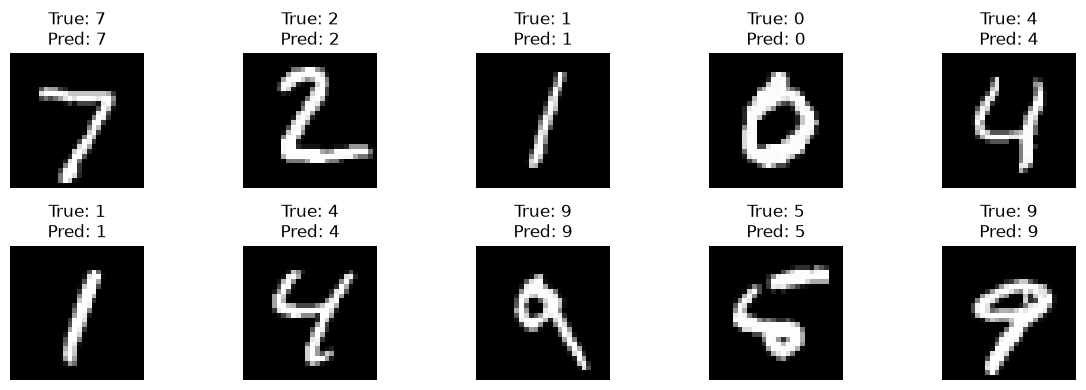

In [7]:
y_pred = mlp.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_test[i], cmap='gray')
    plt.title(f'True: {y_test[i]}\nPred: {y_pred_classes[i]}')
    plt.axis('off')
plt.tight_layout()
plt.show()

In [8]:
FASHION_MNIST_MEAN, FASHION_MNIST_STD = 0.2860, 0.3530

KEEP_CLASSES = [0, 1, 2, 3, 7]
CLASS_NAMES = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Sneaker"]

LABEL_MAP = {old: new for new, old in enumerate(KEEP_CLASSES)}

In [9]:
def filter_and_remap(x, y):
    keep_mask = np.isin(y, KEEP_CLASSES)
    x_filtered = x[keep_mask]
    y_filtered = y[keep_mask]
    y_remapped = np.vectorize(LABEL_MAP.get)(y_filtered)
    return x_filtered, y_remapped

In [10]:
def load_fashion_mnist_5classes():
    (train_x, train_y), (test_x, test_y) = fashion_mnist.load_data()

    train_x = (train_x.astype("float32") / 255.0 - FASHION_MNIST_MEAN) / FASHION_MNIST_STD
    test_x = (test_x.astype("float32") / 255.0 - FASHION_MNIST_MEAN) / FASHION_MNIST_STD

    train_x, train_y = filter_and_remap(train_x, train_y)
    test_x, test_y = filter_and_remap(test_x, test_y)
    return (train_x, train_y), (test_x, test_y)

In [11]:
(train_x, train_y), (test_x, test_y) = load_fashion_mnist_5classes()

In [12]:
NUM_DIGIT_CLASSES = 5

input_layer = layers.Input(shape=(28, 28))

x = input_layer
for layer in mlp.layers[:-1]:
    x = layer(x)
    layer.trainable = False

x = layers.Dense(NUM_DIGIT_CLASSES, activation='softmax', name="fashion_head")(x)

In [13]:
transfer_model = Model(inputs=input_layer, outputs=x)

transfer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=["accuracy"],
)

transfer_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fashion_head (Dense)            │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,061 (426.02 KB)

 Trainable params: 325 (1.27 KB)

 Non-trainable params: 108,736 (424.75 KB)

In [14]:
history_transfer = transfer_model.fit(
    train_x, train_y,
    validation_data=(test_x, test_y),
    batch_size=128,
    epochs=40,
    verbose=1
)

Epoch 1/40


I0000 00:00:1788352274.854205  750030 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_28493__.15


232/235 ━━━━━━━━━━━━━━━━━━━━ 0s 653us/step - accuracy: 0.3786 - loss: 5.7859

I0000 00:00:1788352276.129813  750029 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_28493__.15


235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.3804 - loss: 5.7535 - val_accuracy: 0.6896 - val_loss: 0.9978
Epoch 2/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 870us/step - accuracy: 0.6073 - loss: 1.6914 - val_accuracy: 0.8172 - val_loss: 0.5890
Epoch 3/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 850us/step - accuracy: 0.6966 - loss: 1.0066 - val_accuracy: 0.8530 - val_loss: 0.5205
Epoch 4/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 865us/step - accuracy: 0.7347 - loss: 0.7922 - val_accuracy: 0.8556 - val_loss: 0.5233
Epoch 5/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 861us/step - accuracy: 0.7485 - loss: 0.7262 - val_accuracy: 0.8630 - val_loss: 0.5164
Epoch 6/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 853us/step - accuracy: 0.7531 - loss: 0.7052 - val_accuracy: 0.8546 - val_loss: 0.5211
Epoch 7/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 872us/step - accuracy: 0.7599 - loss: 0.6796 - val_accuracy: 0.8566 - val_loss: 0.5301
Epoch 8/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 850us/step - accuracy: 0.7631 - loss: 0.6592 - val_accuracy

In [15]:
test_acc = transfer_model.evaluate(test_x, test_y, verbose=0)[1]
print(f"Transfer Model Accuracy: {test_acc:.4f}")

Transfer Model Accuracy: 0.8602


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


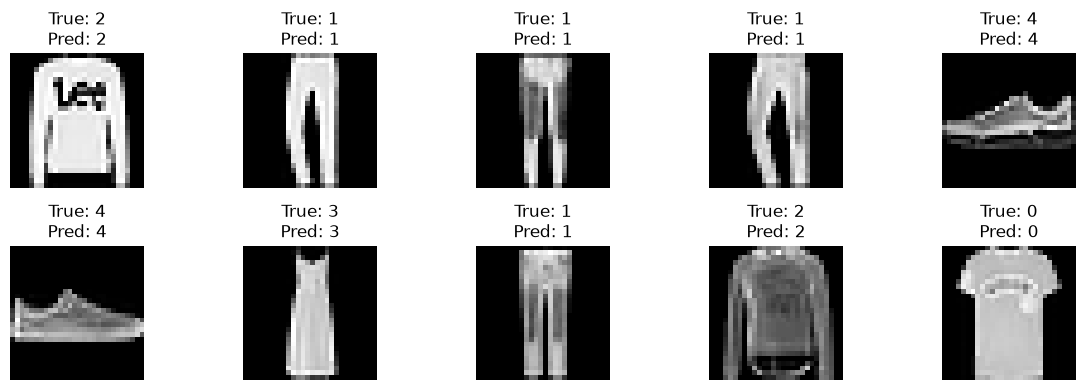

In [16]:
y_pred_t = transfer_model.predict(test_x)
y_pred_classes_t = np.argmax(y_pred_t, axis=1)

plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(test_x[i], cmap='gray')
    plt.title(f'True: {test_y[i]}\nPred: {y_pred_classes_t[i]}')
    plt.axis('off')
plt.tight_layout()
plt.show()

In [17]:
for layer in transfer_model.layers[:-1]:
    layer.trainable = True

transfer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)

In [18]:
transfer_model.fit(
    train_x, train_y,
    validation_data=(test_x, test_y),
    batch_size=128,
    epochs=30,
    verbose=1
)

Epoch 1/30


/home/mlguest/miniforge3/envs/ml/lib/python3.12/site-packages/keras/src/backend/tensorflow/nn.py:1402: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(
I0000 00:00:1788352288.604555  750030 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_76985__.15


230/235 ━━━━━━━━━━━━━━━━━━━━ 0s 661us/step - accuracy: 0.7878 - loss: 0.5714

I0000 00:00:1788352289.724885  750029 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_76985__.15
I0000 00:00:1788352289.982782  754575 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_18', 20 bytes spill stores, 20 bytes spill loads



235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7884 - loss: 0.5705 - val_accuracy: 0.8636 - val_loss: 0.4301
Epoch 2/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 878us/step - accuracy: 0.8076 - loss: 0.5254 - val_accuracy: 0.8760 - val_loss: 0.3963
Epoch 3/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 897us/step - accuracy: 0.8248 - loss: 0.4882 - val_accuracy: 0.8812 - val_loss: 0.3717
Epoch 4/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 872us/step - accuracy: 0.8369 - loss: 0.4611 - val_accuracy: 0.8878 - val_loss: 0.3523
Epoch 5/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 885us/step - accuracy: 0.8474 - loss: 0.4354 - val_accuracy: 0.8924 - val_loss: 0.3382
Epoch 6/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 879us/step - accuracy: 0.8515 - loss: 0.4249 - val_accuracy: 0.8966 - val_loss: 0.3260
Epoch 7/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 893us/step - accuracy: 0.8615 - loss: 0.4020 - val_accuracy: 0.8998 - val_loss: 0.3153
Epoch 8/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 882us/step - accuracy: 0.8637 - loss: 0.3937 - val_accuracy:

In [19]:
test_acc_finetune = transfer_model.evaluate(test_x, test_y, verbose=0)[1]
print(f"Transfer Model Accuracy: {test_acc_finetune:.4f}")

Transfer Model Accuracy: 0.9262


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


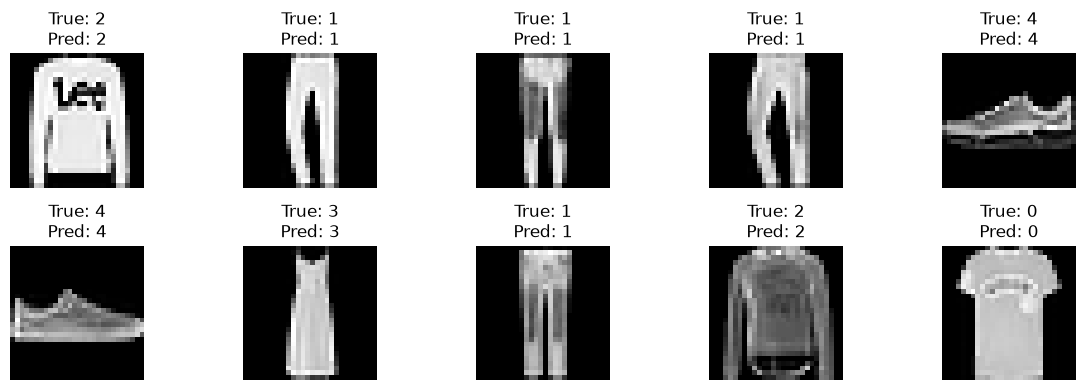

In [20]:
y_pred_t = transfer_model.predict(test_x)
y_pred_classes_t = np.argmax(y_pred_t, axis=1)

plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(test_x[i], cmap='gray')
    plt.title(f'True: {test_y[i]}\nPred: {y_pred_classes_t[i]}')
    plt.axis('off')
plt.tight_layout()
plt.show()